In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


In [2]:
from scipy.signal import find_peaks

def load_file_one_go(files, chunk_size, baseline_window_ns, channel):
    prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin='zero',
    )
    time_ns = prerocessed_data["time_ns"]
    voltage_mV = prerocessed_data["voltage_mV"]

    preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in ['is_saturated', 'n_saturated_samples']}
    preprocessed_event_info.update({ 
        'event_file': prerocessed_data['event_file'],
        'event_segment': prerocessed_data['event_segment']
    })

    df = build_waveform_feature_dataframe(
        time_ns,
        voltage_mV,
        peak_threshold_mV=None,
        second_peak_min_height_frac=0.2,
        pre_peak_ns = 20,
        post_peak_ns = 80,
        pre_rise_ns = 10, 
        post_rise_ns = 80, 
        extra=preprocessed_event_info 
    )
    cutflow = CutFlow(len(df))

    cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
    cutflow.print()

    df_sel = df[cutflow.mask].copy()
    waveforms_sel = voltage_mV[cutflow.mask]

    return time_ns, waveforms_sel, df_sel


# Configuration

In [3]:
chunk_size = 512 
baseline_window_width_ns = 20
basic_plots=True

baseline_window_ns = (0 ,20)


# Select Files


In [ ]:
# data_dir = Path("data/WA0089/LED_sweep/260625/850V_525MHz")
# channel = "Channel 2"
# # file_name = "led_080"
# file_name = "led_100" ## ok


# data_dir = Path("data/WA0089/LED_sweep/260615")
# channel = "Channel 1"
# file_name = "WA0089_850V_20MHz_Cold_led1" ## not ok

channel = "Channel 4"
data_dir = 'data/WA0089/260702'
# file_name = 'led000_LOW_850V_525MHz' # ok
# file_name = 'led000_LOW_850V_20MHz' # ok
# file_name = 'led000_HIGH_850V_525MHz' # ok
# file_name = 'led000_HIGH_850V_20MHz' # ok



In [5]:
t, wfs, df =  load_file_one_go([f"{data_dir}/{file_name}-{i}.h5" for i in range(1, 2)], chunk_size, baseline_window_ns, channel)

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31411       99.1%         99.1%


# Focus on one thing

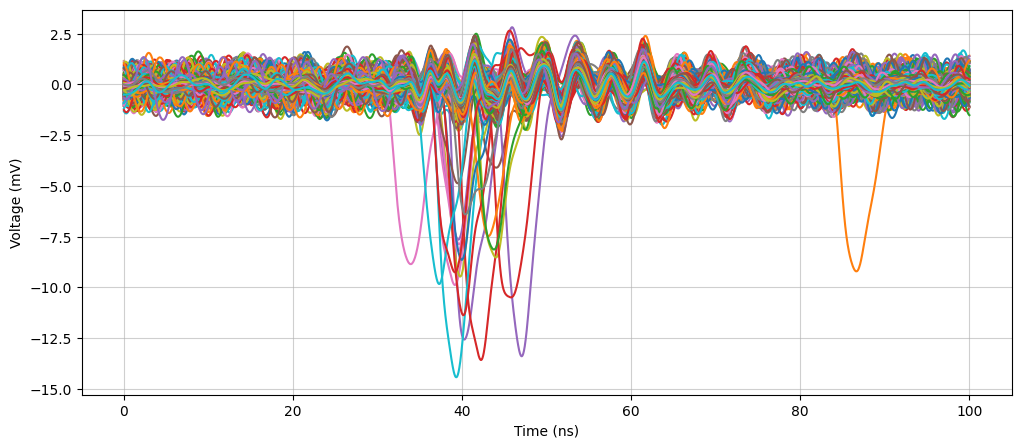

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
add_plot_waveforms(axes, t, wfs[:3000], title='')

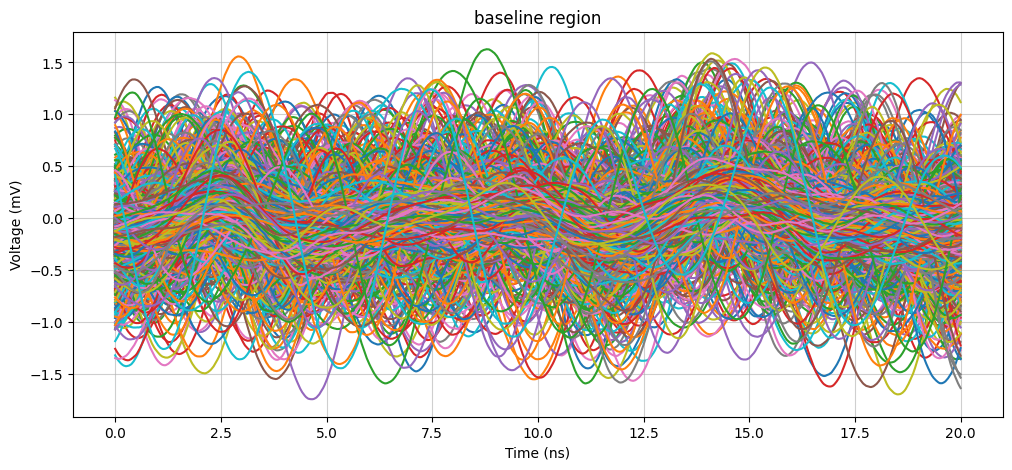

In [7]:
mask = (t >= baseline_window_ns[0]) & (t <= baseline_window_ns[1])
baseline_region = wfs[:, mask]
fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
add_plot_waveforms(axes, t[mask], baseline_region[:5000], title='baseline region')

In [8]:
pedestal = baseline_region.mean(axis=1)
rms = baseline_region.std(axis=1, ddof=1)

print("Mean pedestal:", pedestal.mean())
print("Pedestal spread:", pedestal.std(ddof=1))
print("Mean RMS noise:", rms.mean())
print("RMS noise spread:", rms.std(ddof=1))



Mean pedestal: 7.937641e-09
Pedestal spread: 1.211519e-07
Mean RMS noise: 0.18343568
RMS noise spread: 0.09821704


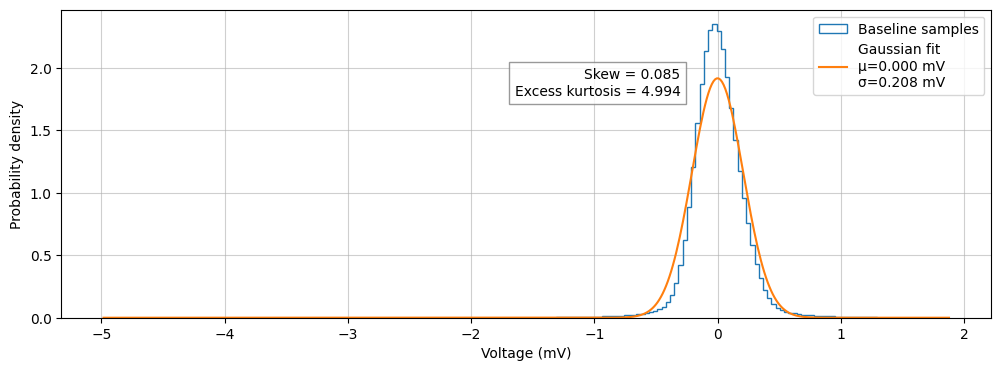

In [20]:
from scipy.stats import norm
from scipy.stats import skew, kurtosis


samples = baseline_region.ravel()

mu, sigma = norm.fit(samples)

x = np.linspace(samples.min(), samples.max(), 500)

plt.figure(figsize=(12,4))
plt.hist(samples, bins=200, density=True, histtype='step', label='Baseline samples')
plt.plot(x, norm.pdf(x, mu, sigma), label=f'Gaussian fit\nμ={mu:.3f} mV\nσ={sigma:.3f} mV')


sk = skew(samples)
kurt = kurtosis(samples)


stats_text = (
    f"Skew = {sk:.3f}\n"
    f"Excess kurtosis = {kurt:.3f}"
)

plt.text(
    -0.3, 2.0,
    stats_text,
    ha='right',
    va='top',
    bbox=dict(facecolor='white',
              alpha=0.8,
              edgecolor='gray')
)

plt.xlabel("Voltage (mV)")
plt.ylabel("Probability density")
plt.legend();

Text(0.5, 1.0, 'Gaussian Q-Q plot')

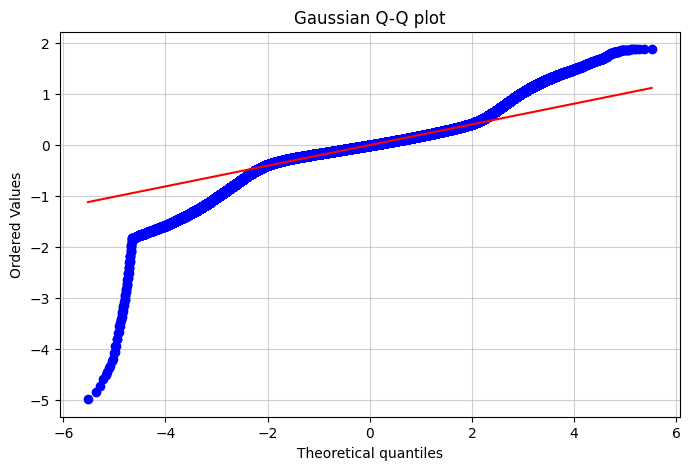

In [10]:
from scipy import stats

stats.probplot(samples, dist="norm", plot=plt)
plt.title("Gaussian Q-Q plot")

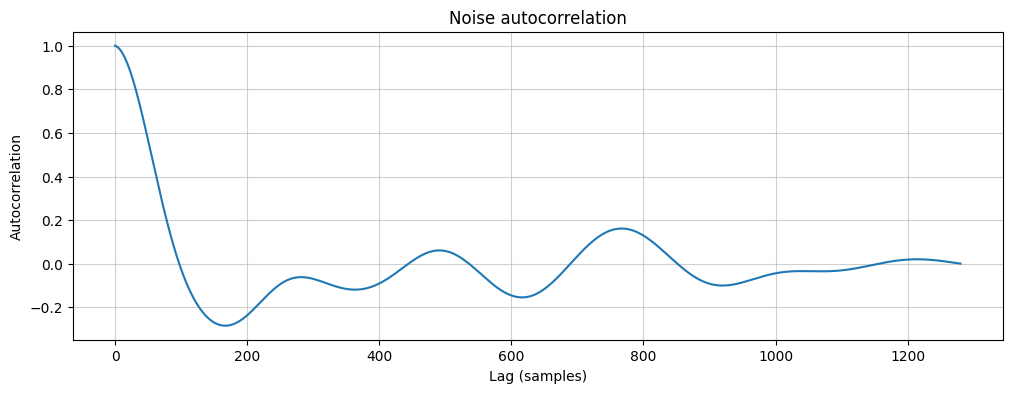

In [11]:
from scipy.signal import correlate

corr = np.zeros(baseline_region.shape[1])

for wf in baseline_region:
    c = correlate(wf, wf, mode='full')
    c = c[c.size//2:]
    corr += c / c[0]          # normalize

corr /= len(baseline_region)

lags = np.arange(len(corr))

plt.figure(figsize=(12,4))
plt.plot(lags, corr)
plt.title("Noise autocorrelation")
plt.xlabel("Lag (samples)")
plt.ylabel("Autocorrelation")
plt.grid(True)

Sampling step: 0.01562 ns


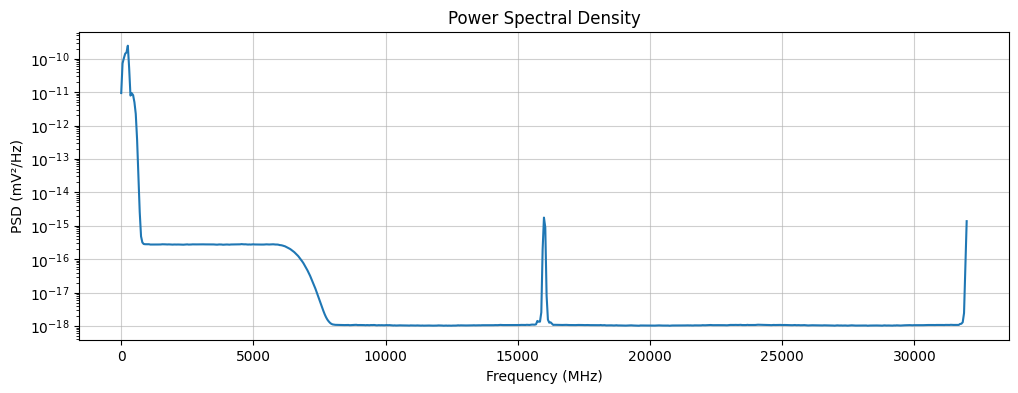

In [12]:
from scipy.signal import welch

dt = np.median(np.diff(t))
print(f"Sampling step: {dt:.5f} ns")
fs = 1 / (dt * 1e-9)          # sampling frequency (Hz)

psds = []

for wf in baseline_region:
    f, Pxx = welch( wf, fs=fs, nperseg=len(wf), detrend='constant')
    psds.append(Pxx)

psd = np.mean(psds, axis=0)

plt.figure(figsize=(12,4))
plt.semilogy(f/1e6, psd)

plt.title("Power Spectral Density")
plt.xlabel("Frequency (MHz)")
plt.ylabel("PSD (mV²/Hz)")
plt.grid(True)

Text(0, 0.5, 'Sample')

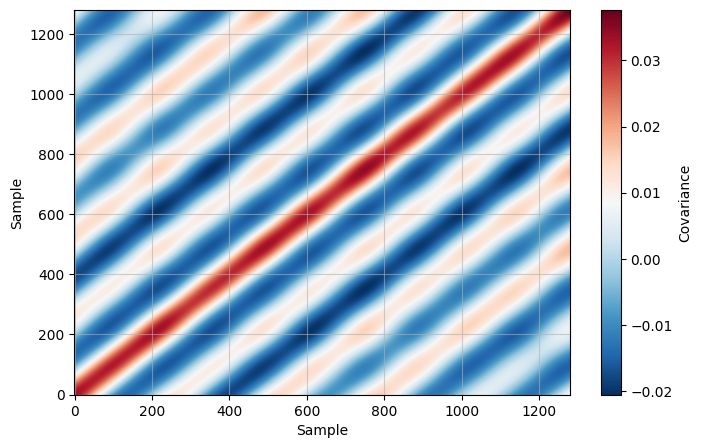

In [13]:
C = np.cov(baseline_region.T)

plt.imshow(C,
           origin='lower',
           cmap='RdBu_r',
           aspect='auto')
plt.colorbar(label="Covariance")
plt.xlabel("Sample")
plt.ylabel("Sample")

In [14]:
C = np.cov(baseline_region.T, bias=False)
print(np.mean(np.diag(C)))
print(np.var(baseline_region))

0.031826451958273314
0.04326113
